In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import cftime
import calendar
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.path as mpath
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.ticker as mticker
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Rectangle
import matplotlib.dates as mdates
import imageio
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import datetime #import datetime
from glob import glob
from scipy import signal
import seaborn as sns

In [2]:
def shift_one_month_back(t):
    if t.month == 1:
        return cftime.DatetimeNoLeap(t.year - 1, 12, t.day, t.hour, t.minute, t.second)
    else:
        return cftime.DatetimeNoLeap(t.year, t.month - 1, t.day, t.hour, t.minute, t.second)
"""
shifted_time = np.array([shift_one_month_back(t) for t in ds_22['time'].values])
ds_22 = ds_22.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_19_c['time'].values])
ds_19_c = ds_19_c.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_24['time'].values])
ds_24 = ds_24.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_1825['time'].values])
ds_1825 = ds_1825.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_1825_17tg['time'].values])
ds_1825_17tg = ds_1825_17tg.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_1tg['time'].values])
ds_1tg = ds_1tg.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_1pr['time'].values])
ds_1pr = ds_1pr.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_60tg['time'].values])
ds_60tg = ds_60tg.assign_coords(time=shifted_time)
"""

"\nshifted_time = np.array([shift_one_month_back(t) for t in ds_22['time'].values])\nds_22 = ds_22.assign_coords(time=shifted_time)\n\nshifted_time = np.array([shift_one_month_back(t) for t in ds_19_c['time'].values])\nds_19_c = ds_19_c.assign_coords(time=shifted_time)\n\nshifted_time = np.array([shift_one_month_back(t) for t in ds_24['time'].values])\nds_24 = ds_24.assign_coords(time=shifted_time)\n\nshifted_time = np.array([shift_one_month_back(t) for t in ds_1825['time'].values])\nds_1825 = ds_1825.assign_coords(time=shifted_time)\n\nshifted_time = np.array([shift_one_month_back(t) for t in ds_1825_17tg['time'].values])\nds_1825_17tg = ds_1825_17tg.assign_coords(time=shifted_time)\n\nshifted_time = np.array([shift_one_month_back(t) for t in ds_1tg['time'].values])\nds_1tg = ds_1tg.assign_coords(time=shifted_time)\n\nshifted_time = np.array([shift_one_month_back(t) for t in ds_1pr['time'].values])\nds_1pr = ds_1pr.assign_coords(time=shifted_time)\n\nshifted_time = np.array([shift_one

In [3]:
"""lat_22 = ds_22["lat"]
weighted_lat_22 = np.cos(np.deg2rad(lat_22))
lat_19_c = ds_19_c["lat"]
weighted_lat_19_c = np.cos(np.deg2rad(lat_19_c))
lat_24 = ds_24["lat"]
weighted_lat_24 = np.cos(np.deg2rad(lat_24))
lat_1825 = ds_1825["lat"]
weighted_lat_1825 = np.cos(np.deg2rad(lat_1825))
lat_1825_17tg = ds_1825_17tg["lat"]
weighted_lat_1825_17tg = np.cos(np.deg2rad(lat_1825_17tg))
lat_1tg = ds_1tg["lat"]
weighted_lat_1tg = np.cos(np.deg2rad(lat_1tg))
lat_1pr = ds_1pr["lat"]
weighted_lat_1pr = np.cos(np.deg2rad(lat_1pr))
lat_60tg = ds_60tg["lat"]
weighted_lat_60tg = np.cos(np.deg2rad(lat_60tg))"""

'lat_22 = ds_22["lat"]\nweighted_lat_22 = np.cos(np.deg2rad(lat_22))\nlat_19_c = ds_19_c["lat"]\nweighted_lat_19_c = np.cos(np.deg2rad(lat_19_c))\nlat_24 = ds_24["lat"]\nweighted_lat_24 = np.cos(np.deg2rad(lat_24))\nlat_1825 = ds_1825["lat"]\nweighted_lat_1825 = np.cos(np.deg2rad(lat_1825))\nlat_1825_17tg = ds_1825_17tg["lat"]\nweighted_lat_1825_17tg = np.cos(np.deg2rad(lat_1825_17tg))\nlat_1tg = ds_1tg["lat"]\nweighted_lat_1tg = np.cos(np.deg2rad(lat_1tg))\nlat_1pr = ds_1pr["lat"]\nweighted_lat_1pr = np.cos(np.deg2rad(lat_1pr))\nlat_60tg = ds_60tg["lat"]\nweighted_lat_60tg = np.cos(np.deg2rad(lat_60tg))'

In [4]:
so2_19 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/SO2_h0_1975-2014.nc")
shifted_time_19 = np.array([shift_one_month_back(t) for t in so2_19['time'].values])
so2_19 = so2_19.assign_coords(time=shifted_time_19)
so2_19_c = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg19/NHIST_tropstratchem_f09_tn14_20260116_Pinatubo10Tg19_02/SO2_h0_1991-1995.nc")
shifted_time_19_c = np.array([shift_one_month_back(t) for t in so2_19_c['time'].values])
so2_19_c = so2_19_c.assign_coords(time=shifted_time_19_c)
so2_22 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10Tg22/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01/SO2_h0_1991-1995.nc")
shifted_time_22 = np.array([shift_one_month_back(t) for t in so2_22['time'].values])
so2_22 = so2_22.assign_coords(time=shifted_time_22)
so2_24 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg24/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01/SO2_h0_1991-1995.nc")
shifted_time_24 = np.array([shift_one_month_back(t) for t in so2_24['time'].values])
so2_24 = so2_24.assign_coords(time=shifted_time_24)
so2_1825_17tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg1825/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01/SO2_h0_1991-1995.nc")
shifted_time_1825_17tg = np.array([shift_one_month_back(t) for t in so2_1825_17tg['time'].values])
so2_1825_17tg = so2_1825_17tg.assign_coords(time=shifted_time_1825_17tg)
so2_1825 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg1825/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01/SO2_h0_1991-1995.nc")
shifted_time_1825 = np.array([shift_one_month_back(t) for t in so2_1825['time'].values])
so2_1825 = so2_1825.assign_coords(time=shifted_time_1825)
so2_1tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_1tg19/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01/SO2_h0_1991-1995.nc")
shifted_time_1tg = np.array([shift_one_month_back(t) for t in so2_1tg['time'].values])
so2_1tg = so2_1tg.assign_coords(time=shifted_time_1tg)
so2_1pr = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg_1pr/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr/SO2_h0_1991-1995.nc")
shifted_time_1pr = np.array([shift_one_month_back(t) for t in so2_1pr['time'].values])
so2_1pr = so2_1pr.assign_coords(time=shifted_time_1pr)
so2_60tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_60tg19/NHIST_tropstratchem_f09_tn14_20260107_Pinatubo60Tg19/SO2_h0_1991-1995.nc")
shifted_time_60tg = np.array([shift_one_month_back(t) for t in so2_60tg['time'].values])
so2_60tg = so2_60tg.assign_coords(time=shifted_time_60tg)

In [5]:
lat = so2_19["lat"]
weighted_lat_19 = np.cos(np.deg2rad(lat))
lat = so2_19_c["lat"]
weighted_lat_19_c = np.cos(np.deg2rad(lat))
lat = so2_22["lat"]
weighted_lat_22 = np.cos(np.deg2rad(lat))
lat = so2_24["lat"]
weighted_lat_24 = np.cos(np.deg2rad(lat))
lat = so2_1825["lat"]
weighted_lat_1825 = np.cos(np.deg2rad(lat))
lat = so2_1825_17tg["lat"]
weighted_lat_1825_17tg = np.cos(np.deg2rad(lat))
lat = so2_1tg["lat"]
weighted_lat_1tg = np.cos(np.deg2rad(lat))
lat = so2_1pr["lat"]
weighted_lat_1pr = np.cos(np.deg2rad(lat))
lat = so2_60tg["lat"]
weighted_lat_60tg = np.cos(np.deg2rad(lat))

In [11]:
aod_19 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/AOD_VIS_h0_1975-2014.nc")
shifted_time_19 = np.array([shift_one_month_back(t) for t in aod_19['time'].values])
aod_19 = aod_19.assign_coords(time=shifted_time_19)
aod_19_c = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg19/NHIST_tropstratchem_f09_tn14_20260116_Pinatubo10Tg19_02/AOD_VIS_h0_1991-1995.nc")
shifted_time_19_c = np.array([shift_one_month_back(t) for t in aod_19_c['time'].values])
aod_19_c = aod_19_c.assign_coords(time=shifted_time_19_c)
aod_22 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10Tg22/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01/AOD_VIS_h0_1991-1995.nc")
shifted_time_22 = np.array([shift_one_month_back(t) for t in aod_22['time'].values])
aod_22 = aod_22.assign_coords(time=shifted_time_22)
aod_24 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg24/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01/AOD_VIS_h0_1991-1995.nc")
shifted_time_24 = np.array([shift_one_month_back(t) for t in aod_24['time'].values])
aod_24 = aod_24.assign_coords(time=shifted_time_24)
aod_1825_17tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg1825/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01/AOD_VIS_h0_1991-1995.nc")
shifted_time_1825_17tg = np.array([shift_one_month_back(t) for t in aod_1825_17tg['time'].values])
aod_1825_17tg = aod_1825_17tg.assign_coords(time=shifted_time_1825_17tg)
aod_1825 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg1825/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01/AOD_VIS_h0_1991-1995.nc")
shifted_time_1825 = np.array([shift_one_month_back(t) for t in aod_1825['time'].values])
aod_1825 = aod_1825.assign_coords(time=shifted_time_1825)
aod_1tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_1tg19/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01/AOD_VIS_h0_1991-1995.nc")
shifted_time_1tg = np.array([shift_one_month_back(t) for t in aod_1tg['time'].values])
aod_1tg = aod_1tg.assign_coords(time=shifted_time_1tg)
aod_1pr = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg_1pr/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr/AOD_VIS_h0_1991-1995.nc")
shifted_time_1pr = np.array([shift_one_month_back(t) for t in aod_1pr['time'].values])
aod_1pr = aod_1pr.assign_coords(time=shifted_time_1pr)
aod_60tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_60tg19/NHIST_tropstratchem_f09_tn14_20260107_Pinatubo60Tg19/AOD_VIS_h0_1991-1995.nc")
shifted_time_60tg = np.array([shift_one_month_back(t) for t in aod_60tg['time'].values])
aod_60tg = aod_60tg.assign_coords(time=shifted_time_60tg)

In [12]:
day_19 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/DAYFOC_h0_1975-2014.nc")
shifted_time_19 = np.array([shift_one_month_back(t) for t in day_19['time'].values])
day_19 = day_19.assign_coords(time=shifted_time_19)
day_19_c = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg19/NHIST_tropstratchem_f09_tn14_20260116_Pinatubo10Tg19_02/DAYFOC_h0_1991-1995.nc")
shifted_time_19_c = np.array([shift_one_month_back(t) for t in day_19_c['time'].values])
day_19_c = day_19_c.assign_coords(time=shifted_time_19_c)
day_22 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10Tg22/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01/DAYFOC_h0_1991-1995.nc")
shifted_time_22 = np.array([shift_one_month_back(t) for t in day_22['time'].values])
day_22 = day_22.assign_coords(time=shifted_time_22)
day_24 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg24/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01/DAYFOC_h0_1991-1995.nc")
shifted_time_24 = np.array([shift_one_month_back(t) for t in day_24['time'].values])
day_24 = day_24.assign_coords(time=shifted_time_24)
day_1825_17tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg1825/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01/DAYFOC_h0_1991-1995.nc")
shifted_time_1825_17tg = np.array([shift_one_month_back(t) for t in day_1825_17tg['time'].values])
day_1825_17tg = day_1825_17tg.assign_coords(time=shifted_time_1825_17tg)
day_1825 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg1825/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01/DAYFOC_h0_1991-1995.nc")
shifted_time_1825 = np.array([shift_one_month_back(t) for t in day_1825['time'].values])
day_1825 = day_1825.assign_coords(time=shifted_time_1825)
day_1tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_1tg19/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01/DAYFOC_h0_1991-1995.nc")
shifted_time_1tg = np.array([shift_one_month_back(t) for t in day_1tg['time'].values])
day_1tg = day_1tg.assign_coords(time=shifted_time_1tg)
day_1pr = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg_1pr/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr/DAYFOC_h0_1991-1995.nc")
shifted_time_1pr = np.array([shift_one_month_back(t) for t in day_1pr['time'].values])
day_1pr = day_1pr.assign_coords(time=shifted_time_1pr)
day_60tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_60tg19/NHIST_tropstratchem_f09_tn14_20260107_Pinatubo60Tg19/DAYFOC_h0_1991-1995.nc")
shifted_time_60tg = np.array([shift_one_month_back(t) for t in day_60tg['time'].values])
day_60tg = day_60tg.assign_coords(time=shifted_time_60tg)

In [13]:
aod_19_back = aod_19["AOD_VIS"].weighted(weighted_lat_19).mean(dim=["lat", "lon"])
daylight_monthly_19_back = day_19["DAYFOC"].weighted(weighted_lat_19).mean(dim=["lat", "lon"])
aod_19_background = aod_19_back/daylight_monthly_19_back
aod_19_base = aod_19_background.sel(time=slice("1986-01", "1990-12"))
aod_19_clim = aod_19_base.groupby("time.month").mean("time")

In [14]:
aod_19 = aod_19["AOD_VIS"].weighted(weighted_lat_19).mean(dim=["lat", "lon"])
daylight_monthly_19 = day_19["DAYFOC"].weighted(weighted_lat_19).mean(dim=["lat", "lon"])
aod_19 = aod_19/daylight_monthly_19
aod_19 = aod_19.sel(time=slice("1991-01", "1995-12"))
aod_19 = aod_19.groupby("time.month") - aod_19_clim
aod_19_max = max(aod_19)
aod_19_max.values

array(0.11007318)

In [15]:
aod_19_c = aod_19_c["AOD_VIS"].weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])
daylight_monthly_19_c = day_19_c["DAYFOC"].weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])
aod_19_c = aod_19_c/daylight_monthly_19_c
aod_19_c = aod_19_c.groupby("time.month") - aod_19_clim
aod_19_c_max = max(aod_19_c)
aod_19_c_max.values

array(0.09833889)

In [16]:
aod_60tg = aod_60tg["AOD_VIS"].weighted(weighted_lat_60tg).mean(dim=["lat", "lon"])
daylight_monthly_60tg = day_60tg["DAYFOC"].weighted(weighted_lat_60tg).mean(dim=["lat", "lon"])
aod_60tg = aod_60tg/daylight_monthly_60tg
aod_60tg = aod_60tg.groupby("time.month") - aod_19_clim
aod_60tg_max = max(aod_60tg)
aod_60tg_max.values

array(0.68066743)

In [17]:
aod_22 = aod_22["AOD_VIS"].weighted(weighted_lat_22).mean(dim=["lat", "lon"])
daylight_monthly_22 = day_22["DAYFOC"].weighted(weighted_lat_22).mean(dim=["lat", "lon"])
aod_22 = aod_22/daylight_monthly_22
aod_22 = aod_22.groupby("time.month") - aod_19_clim
aod_22_max = max(aod_22)
aod_24 = aod_24["AOD_VIS"].weighted(weighted_lat_24).mean(dim=["lat", "lon"])
daylight_monthly_24 = day_24["DAYFOC"].weighted(weighted_lat_24).mean(dim=["lat", "lon"])
aod_24 = aod_24/daylight_monthly_24
aod_24 = aod_24.groupby("time.month") - aod_19_clim
aod_24_max = max(aod_24)
aod_1825 = aod_1825["AOD_VIS"].weighted(weighted_lat_1825).mean(dim=["lat", "lon"])
daylight_monthly_1825 = day_1825["DAYFOC"].weighted(weighted_lat_1825).mean(dim=["lat", "lon"])
aod_1825 = aod_1825/daylight_monthly_1825
aod_1825 = aod_1825.groupby("time.month") - aod_19_clim
aod_1825_max = max(aod_1825)
aod_1825_17tg = aod_1825_17tg["AOD_VIS"].weighted(weighted_lat_1825_17tg).mean(dim=["lat", "lon"])
daylight_monthly_1825_17tg = day_1825_17tg["DAYFOC"].weighted(weighted_lat_1825_17tg).mean(dim=["lat", "lon"])
aod_1825_17tg = aod_1825_17tg/daylight_monthly_1825_17tg
aod_1825_17tg = aod_1825_17tg.groupby("time.month") - aod_19_clim
aod_1825_17tg_max = max(aod_1825_17tg)
aod_1tg = aod_1tg["AOD_VIS"].weighted(weighted_lat_1tg).mean(dim=["lat", "lon"])
daylight_monthly_1tg = day_1tg["DAYFOC"].weighted(weighted_lat_1tg).mean(dim=["lat", "lon"])
aod_1tg = aod_1tg/daylight_monthly_1tg
aod_1tg = aod_1tg.groupby("time.month") - aod_19_clim
aod_1tg_max = max(aod_1tg)
aod_1pr = aod_1pr["AOD_VIS"].weighted(weighted_lat_1pr).mean(dim=["lat", "lon"])
daylight_monthly_1pr = day_1pr["DAYFOC"].weighted(weighted_lat_1pr).mean(dim=["lat", "lon"])
aod_1pr = aod_1pr/daylight_monthly_1pr
aod_1pr = aod_1pr.groupby("time.month") - aod_19_clim
aod_1pr_max = max(aod_1pr)

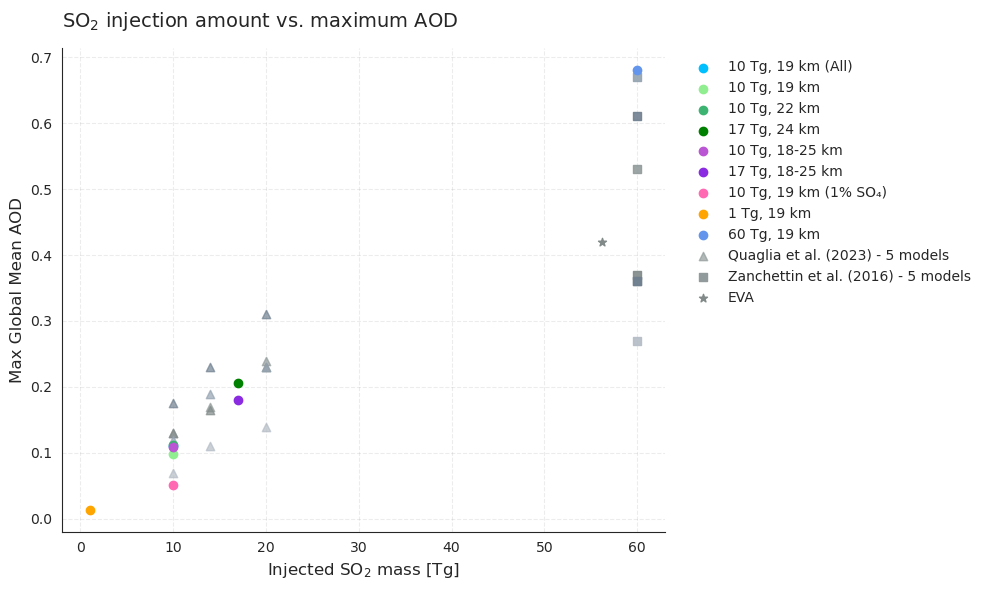

In [18]:
sns.set_style("white")
fig, ax = plt.subplots(figsize=(10, 6))
ax.grid(color="gray", alpha=0.15, linestyle="--", zorder=0)

# Own runs with NorESM2.3 (circles)           
ax.scatter(10, aod_19_max, color="deepskyblue", label="10 Tg, 19 km (All)", zorder=5)      
ax.scatter(10, aod_19_c_max, color="lightgreen", label="10 Tg, 19 km", zorder=5)
ax.scatter(10, aod_22_max, color="mediumseagreen", label="10 Tg, 22 km", zorder=5)
ax.scatter(17, aod_24_max, color="green", label="17 Tg, 24 km", zorder=5)
ax.scatter(10, aod_1825_max, color="mediumorchid", label="10 Tg, 18-25 km", zorder=5)
ax.scatter(17, aod_1825_17tg_max, color="blueviolet", label="17 Tg, 18-25 km", zorder=5)
ax.scatter(10, aod_1pr_max, color="hotpink", label="10 Tg, 19 km (1% SO₄)", zorder=5)
ax.scatter(1, aod_1tg_max, color="orange", label="1 Tg, 19 km", zorder=5)
ax.scatter(60, aod_60tg_max, color="cornflowerblue", label="60 Tg, 19 km", zorder=5)

# Quaglia et al. 2023 (triangles)
quaglia_color = "lightsteelblue"
ax.scatter([10, 14, 20], [0.13, 0.17, 0.24], marker="^", color="#929b9b", alpha=0.7, label="Quaglia et al. (2023) - 5 models")
ax.scatter([10, 14, 20], [0.13, 0.165, 0.23], marker="^", color="#818989", alpha=0.7)
ax.scatter([10, 14, 20], [0.175, 0.23, 0.31], marker="^", color="#708090", alpha=0.7)
ax.scatter([10, 14, 20], [0.07, 0.11, 0.14], marker="^", color="#b4bcc5", alpha=0.7)
ax.scatter([10, 14, 20], [0.12, 0.19, 0.23], marker="^", color="#94a3b1", alpha=0.7)

# Zanchettin et al. 2015 (squares) 
zanch_models = [
    {"x": 60,   "y": 0.53, "c": "#929b9b", "lab": "UM-UKCA"},     
    {"x": 60,   "y": 0.36, "c": "#818989", "lab": "SOCOL - (band)"},
    {"x": 60,   "y": 0.37, "c": "#818989", "lab": "SOCOL - (point)"},
    {"x": 60,   "y": 0.61, "c": "#708090", "lab": "MAECHAM - (band)"},   
    {"x": 60,   "y": 0.36, "c": "#708090", "lab": "MAECHAM - (point)"},  
    {"x": 60,   "y": 0.67, "c": "#94a3b1", "lab": "CESM-WACCM"},
    {"x": 60,   "y": 0.27, "c": "#b4bcc5", "lab": "M2D-UPMC"}        
]

for m in zanch_models:
    ax.scatter(m["x"], m["y"], marker="s", color=m["c"], alpha=0.9)
ax.scatter([], [], marker="s", color="#929b9b", label="Zanchettin et al. (2016) - 5 models")
ax.scatter(56.2, 0.42, color="#818989", marker = "*", label = "EVA")
ax.set_xlabel("Injected SO$_2$ mass [Tg]", fontsize=12)
ax.set_ylabel("Max Global Mean AOD", fontsize=12)
ax.set_title("SO$_2$ injection amount vs. maximum AOD", loc="left", fontsize=14, pad=15)

ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

sns.despine()
plt.tight_layout()
plt.show()

In [19]:
t_19 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/TREFHT_h0_1975-2014.nc")
shifted_time_19 = np.array([shift_one_month_back(t) for t in t_19['time'].values])
t_19 = t_19.assign_coords(time=shifted_time_19)
t_19_c = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg19/NHIST_tropstratchem_f09_tn14_20260116_Pinatubo10Tg19_02/TREFHT_h0_1991-1995.nc")
shifted_time_19_c = np.array([shift_one_month_back(t) for t in t_19_c['time'].values])
t_19_c = t_19_c.assign_coords(time=shifted_time_19_c)
t_22 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10Tg22/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01/TREFHT_h0_1991-1995.nc")
shifted_time_22 = np.array([shift_one_month_back(t) for t in t_22['time'].values])
t_22 = t_22.assign_coords(time=shifted_time_22)
t_24 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg24/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01/TREFHT_h0_1991-1995.nc")
shifted_time_24 = np.array([shift_one_month_back(t) for t in t_24['time'].values])
t_24 = t_24.assign_coords(time=shifted_time_24)
t_1825_17tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg1825/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01/TREFHT_h0_1991-1995.nc")
shifted_time_1825_17tg = np.array([shift_one_month_back(t) for t in t_1825_17tg['time'].values])
t_1825_17tg = t_1825_17tg.assign_coords(time=shifted_time_1825_17tg)
t_1825 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg1825/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01/TREFHT_h0_1991-1995.nc")
shifted_time_1825 = np.array([shift_one_month_back(t) for t in t_1825['time'].values])
t_1825 = t_1825.assign_coords(time=shifted_time_1825)
t_1tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_1tg19/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01/TREFHT_h0_1991-1995.nc")
shifted_time_1tg = np.array([shift_one_month_back(t) for t in t_1tg['time'].values])
t_1tg = t_1tg.assign_coords(time=shifted_time_1tg)
t_1pr = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg_1pr/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr/TREFHT_h0_1991-1995.nc")
shifted_time_1pr = np.array([shift_one_month_back(t) for t in t_1pr['time'].values])
t_1pr = t_1pr.assign_coords(time=shifted_time_1pr)
t_60tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_60tg19/NHIST_tropstratchem_f09_tn14_20260107_Pinatubo60Tg19/TREFHT_h0_1991-1995.nc")
shifted_time_60tg = np.array([shift_one_month_back(t) for t in t_60tg['time'].values])
t_60tg = t_60tg.assign_coords(time=shifted_time_60tg)

In [20]:
temp_ctrl = t_19["TREFHT"].weighted(weighted_lat_19).mean(dim = ["lat", "lon"]) -273.15
baseline = temp_ctrl.sel(time=slice("1986-01", "1990-12"))
base = baseline.groupby("time.month").mean("time")

In [21]:
temp_19 = t_19["TREFHT"].weighted(weighted_lat_19).mean(dim = ["lat", "lon"]) -273.15
t_anom_19 = temp_19.groupby("time.month") - base
t_anom_19 = t_anom_19.sel(time=slice("1991-01", "1995-12"))
t_anom_19_max = min(t_anom_19)
t_anom_19_max.values

array(-0.63765747)

In [22]:
temp_19_c = t_19_c["TREFHT"].weighted(weighted_lat_19_c).mean(dim = ["lat", "lon"]) -273.15
t_anom_19_c = temp_19_c.groupby("time.month") - base
t_anom_19_c_max = min(t_anom_19_c)
t_anom_19_c_max.values

array(-0.37712043)

In [23]:
temp_60tg = t_60tg["TREFHT"].weighted(weighted_lat_60tg).mean(dim = ["lat", "lon"]) -273.15
t_anom_60tg = temp_60tg.groupby("time.month") - base
t_anom_60tg_max = min(t_anom_60tg)
temp_22 = t_22["TREFHT"].weighted(weighted_lat_22).mean(dim = ["lat", "lon"]) -273.15
t_anom_22 = temp_22.groupby("time.month") - base
t_anom_22max = min(t_anom_22)
temp_24 = t_24["TREFHT"].weighted(weighted_lat_24).mean(dim = ["lat", "lon"]) -273.15
t_anom_24 = temp_24.groupby("time.month") - base
t_anom_24_max = min(t_anom_24)
temp_1825 = t_1825["TREFHT"].weighted(weighted_lat_1825).mean(dim = ["lat", "lon"]) -273.15
t_anom_1825 = temp_1825.groupby("time.month") - base
t_anom_1825_max = min(t_anom_1825)
temp_1825_17tg = t_1825_17tg["TREFHT"].weighted(weighted_lat_1825_17tg).mean(dim = ["lat", "lon"]) -273.15
t_anom_1825_17tg = temp_1825_17tg.groupby("time.month") - base
t_anom_1825_17tg_max = min(t_anom_1825_17tg)
temp_1tg = t_1tg["TREFHT"].weighted(weighted_lat_1tg).mean(dim = ["lat", "lon"]) -273.15
t_anom_1tg = temp_1tg.groupby("time.month") - base
t_anom_1tg_max = min(t_anom_1tg)
temp_1pr = t_1pr["TREFHT"].weighted(weighted_lat_1pr).mean(dim = ["lat", "lon"]) -273.15
t_anom_1pr = temp_1pr.groupby("time.month") - base
t_anom_1pr_max = min(t_anom_1pr)

<>:16: SyntaxWarning: invalid escape sequence '\c'
<>:16: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_3128147/1518078474.py:16: SyntaxWarning: invalid escape sequence '\c'
  ax.set_ylabel("Max temp. anomaly [$^\circ$C]", fontsize=12)


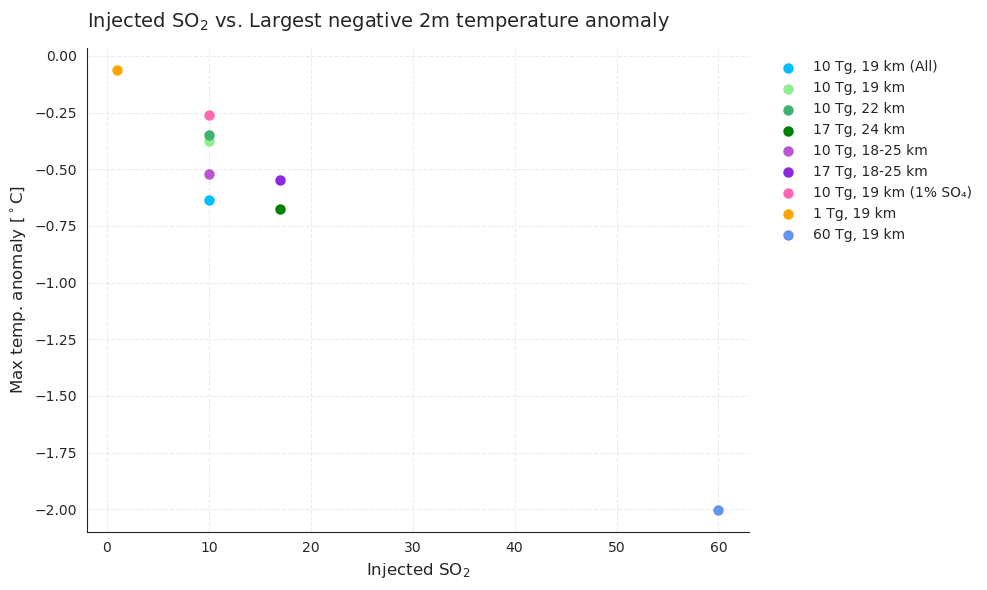

In [24]:
sns.set_style("white")
fig, ax = plt.subplots(figsize=(10, 6))
ax.grid(color="gray", alpha=0.15, linestyle="--", zorder=0)

ax.scatter(10, t_anom_19_max, color="deepskyblue", lw=1.5, label="10 Tg, 19 km (All)")
ax.scatter(10, t_anom_19_c_max, color="lightgreen", lw=1.5,label="10 Tg, 19 km")
ax.scatter(10, t_anom_22max,color="mediumseagreen", lw=1.5,label="10 Tg, 22 km")
ax.scatter(17, t_anom_24_max,color="green", lw=1.5,label="17 Tg, 24 km")
ax.scatter(10, t_anom_1825_max,color="mediumorchid", lw=1.5,label="10 Tg, 18-25 km")
ax.scatter(17, t_anom_1825_17tg_max,color="blueviolet", lw=1.5,label="17 Tg, 18-25 km")
ax.scatter(10, t_anom_1pr_max,color="hotpink", lw=1.5,label="10 Tg, 19 km (1% SO₄)")
ax.scatter(1, t_anom_1tg_max, color="orange", lw=1.5, label="1 Tg, 19 km")
ax.scatter(60, t_anom_60tg_max,color="cornflowerblue", lw=1.5,label="60 Tg, 19 km ")

ax.set_xlabel("Injected SO$_2$", fontsize=12)
ax.set_ylabel("Max temp. anomaly [$^\circ$C]", fontsize=12)
ax.set_title("Injected SO$_2$ vs. Largest negative 2m temperature anomaly", loc="left", fontsize=14, pad=15)

ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

sns.despine()
plt.tight_layout()
plt.show()

<>:10: SyntaxWarning: invalid escape sequence '\c'
<>:10: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_3128147/3335678083.py:10: SyntaxWarning: invalid escape sequence '\c'
  plt.ylabel("Largest abs. temp. anomaly [$^\circ$C]")


Text(0.5, 1.0, 'Max 2m temp anomaly vs. max AOD')

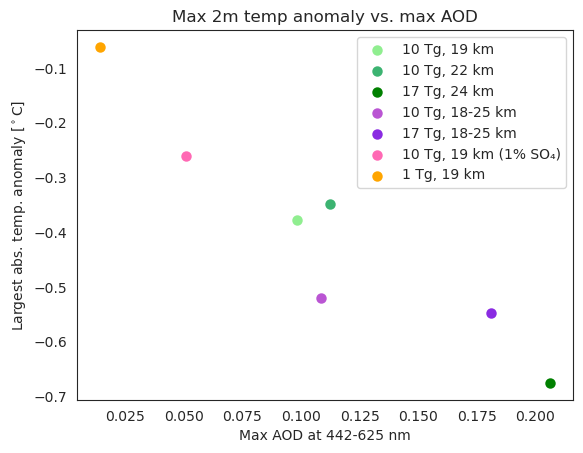

In [25]:
plt.scatter(aod_19_c_max, t_anom_19_c_max, color="lightgreen", lw=1.5,label="10 Tg, 19 km")
plt.scatter(aod_22_max, t_anom_22max,color="mediumseagreen", lw=1.5,label="10 Tg, 22 km")
plt.scatter(aod_24_max, t_anom_24_max,color="green", lw=1.5,label="17 Tg, 24 km")
plt.scatter(aod_1825_max, t_anom_1825_max,color="mediumorchid", lw=1.5,label="10 Tg, 18-25 km")
plt.scatter(aod_1825_17tg_max, t_anom_1825_17tg_max,color="blueviolet", lw=1.5,label="17 Tg, 18-25 km")
plt.scatter(aod_1pr_max, t_anom_1pr_max,color="hotpink", lw=1.5,label="10 Tg, 19 km (1% SO₄)")
plt.scatter(aod_1tg_max, t_anom_1tg_max, color="orange", lw=1.5, label="1 Tg, 19 km")

plt.xlabel("Max AOD at 442-625 nm")
plt.ylabel("Largest abs. temp. anomaly [$^\circ$C]")
plt.legend()
plt.title("Max 2m temp anomaly vs. max AOD")

<>:23: SyntaxWarning: invalid escape sequence '\c'
<>:23: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_3128147/2200690579.py:23: SyntaxWarning: invalid escape sequence '\c'
  ax[1].set_ylabel("Max temperature amomaly [$^\circ$C]")


Text(0.5, 0.98, 'Scatterplots for comparing SO$_2$, AOD, and temperautre anomalies')

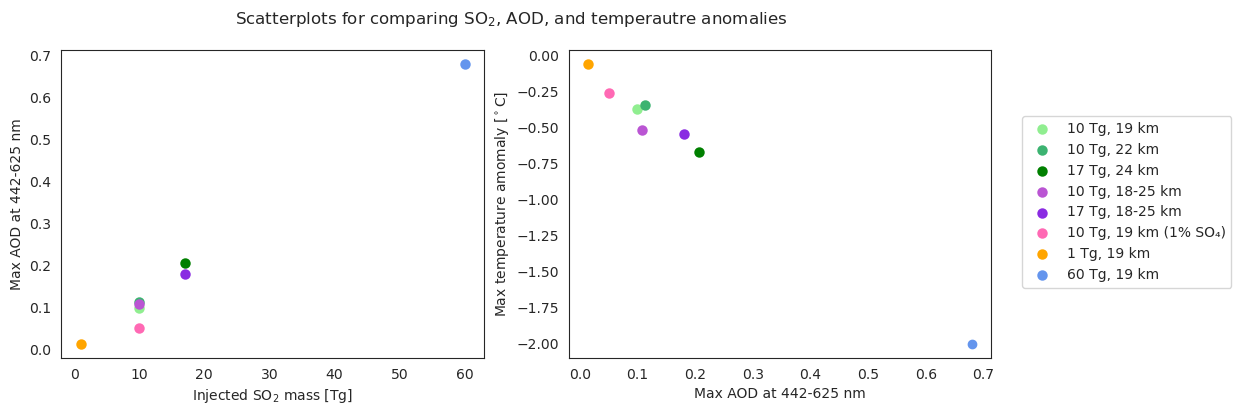

In [26]:
fig, ax = plt.subplots(1,2, figsize=(12, 4), sharex=False)

ax[0].scatter(10, aod_19_c_max, color="lightgreen", lw=1.5,label="10 Tg, 19 km")
ax[0].scatter(10, aod_22_max,color="mediumseagreen", lw=1.5,label="10 Tg, 22 km")
ax[0].scatter(17, aod_24_max,color="green", lw=1.5,label="17 Tg, 24 km")
ax[0].scatter(10, aod_1825_max,color="mediumorchid", lw=1.5,label="10 Tg, 18-25 km")
ax[0].scatter(17, aod_1825_17tg_max,color="blueviolet", lw=1.5,label="17 Tg, 18-25 km")
ax[0].scatter(10, aod_1pr_max,color="hotpink", lw=1.5,label="10 Tg, 19 km (1% SO₄)")
ax[0].scatter(1, aod_1tg_max, color="orange", lw=1.5, label="1 Tg, 19 km")
ax[0].scatter(60, aod_60tg_max,color="cornflowerblue", lw=1.5,label="60 Tg, 19 km ")
ax[0].set_xlabel("Injected SO$_2$ mass [Tg]")
ax[0].set_ylabel("Max AOD at 442-625 nm")

ax[1].scatter(aod_19_c_max, t_anom_19_c_max, color="lightgreen", lw=1.5) #,label="10 Tg, 19 km")
ax[1].scatter(aod_22_max, t_anom_22max,color="mediumseagreen", lw=1.5) #,label="10 Tg, 22 km")
ax[1].scatter(aod_24_max, t_anom_24_max,color="green", lw=1.5) #,label="17 Tg, 24 km")
ax[1].scatter(aod_1825_max, t_anom_1825_max,color="mediumorchid", lw=1.5) #,label="10 Tg, 18-25 km")
ax[1].scatter(aod_1825_17tg_max, t_anom_1825_17tg_max,color="blueviolet", lw=1.5) #,label="17 Tg, 18-25 km")
ax[1].scatter(aod_1pr_max, t_anom_1pr_max,color="hotpink", lw=1.5) #, label="10 Tg, 19 km (1% SO₄)")
ax[1].scatter(aod_1tg_max, t_anom_1tg_max, color="orange", lw=1.5) #, label="1 Tg, 19 km")
ax[1].scatter(aod_60tg_max, t_anom_60tg_max,color="cornflowerblue") #, lw=1.5,label="60 Tg, 19 km ")
ax[1].set_xlabel("Max AOD at 442-625 nm")
ax[1].set_ylabel("Max temperature amomaly [$^\circ$C]")

fig.legend(
    loc="center left",
    bbox_to_anchor=(0.92, 0.5),
    frameon=True
)
#plt.tight_layout
plt.suptitle("Scatterplots for comparing SO$_2$, AOD, and temperautre anomalies")

In [27]:
trop_19 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/TROP_P_h0_1975-2014.nc")
shifted_time_19 = np.array([shift_one_month_back(t) for t in trop_19['time'].values])
trop_19 = trop_19.assign_coords(time=shifted_time_19)
trop_19_c = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg19/NHIST_tropstratchem_f09_tn14_20260116_Pinatubo10Tg19_02/TROP_P_h0_1991-1995.nc")
shifted_time_19_c = np.array([shift_one_month_back(t) for t in trop_19_c['time'].values])
trop_19_c = trop_19_c.assign_coords(time=shifted_time_19_c)
trop_22 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10Tg22/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01/TROP_P_h0_1991-1995.nc")
shifted_time_22 = np.array([shift_one_month_back(t) for t in trop_22['time'].values])
trop_22 = trop_22.assign_coords(time=shifted_time_22)
trop_24 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg24/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01/TROP_P_h0_1991-1995.nc")
shifted_time_24 = np.array([shift_one_month_back(t) for t in trop_24['time'].values])
trop_24 = trop_24.assign_coords(time=shifted_time_24)
trop_1825_17tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg1825/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01/TROP_P_h0_1991-1995.nc")
shifted_time_1825_17tg = np.array([shift_one_month_back(t) for t in trop_1825_17tg['time'].values])
trop_1825_17tg = trop_1825_17tg.assign_coords(time=shifted_time_1825_17tg)
trop_1825 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg1825/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01/TROP_P_h0_1991-1995.nc")
shifted_time_1825 = np.array([shift_one_month_back(t) for t in trop_1825['time'].values])
trop_1825 = trop_1825.assign_coords(time=shifted_time_1825)
trop_1tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_1tg19/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01/TROP_P_h0_1991-1995.nc")
shifted_time_1tg = np.array([shift_one_month_back(t) for t in trop_1tg['time'].values])
trop_1tg = trop_1tg.assign_coords(time=shifted_time_1tg)
trop_1pr = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg_1pr/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr/TROP_P_h0_1991-1995.nc")
shifted_time_1pr = np.array([shift_one_month_back(t) for t in trop_1pr['time'].values])
trop_1pr = trop_1pr.assign_coords(time=shifted_time_1pr)
trop_60tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_60tg19/NHIST_tropstratchem_f09_tn14_20260107_Pinatubo60Tg19/TROP_P_h0_1991-1995.nc")
shifted_time_60tg = np.array([shift_one_month_back(t) for t in trop_60tg['time'].values])
trop_60tg = trop_60tg.assign_coords(time=shifted_time_60tg)

In [28]:
tropopause = trop_19["TROP_P"].weighted(weighted_lat_19).mean(dim=["lat", "lon"])
tropopause_22 = trop_22["TROP_P"].weighted(weighted_lat_22).mean(dim=["lat", "lon"])
tropopause_19_c = trop_19_c["TROP_P"].weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])
tropopause_24 = trop_24["TROP_P"].weighted(weighted_lat_24).mean(dim=["lat", "lon"])
tropopause_1825 = trop_1825["TROP_P"].weighted(weighted_lat_1825).mean(dim=["lat", "lon"])
tropopause_1825_17tg = trop_1825_17tg["TROP_P"].weighted(weighted_lat_1825_17tg).mean(dim=["lat", "lon"])
tropopause_1tg = trop_1tg["TROP_P"].weighted(weighted_lat_1tg).mean(dim=["lat", "lon"])
tropopause_1pr= trop_1pr["TROP_P"].weighted(weighted_lat_1pr).mean(dim=["lat", "lon"])
tropopause_60tg= trop_60tg["TROP_P"].weighted(weighted_lat_60tg).mean(dim=["lat", "lon"])

In [29]:
p_lev = tropopause * 0.01
p_lev_22 = tropopause_22 * 0.01
p_lev_19_c = tropopause_19_c * 0.01
p_lev_24 = tropopause_24 * 0.01
p_lev_1825 = tropopause_1825 * 0.01
p_lev_1825_17tg = tropopause_1825_17tg * 0.01
p_lev_1tg = tropopause_1tg * 0.01
p_lev_1pr = tropopause_1pr * 0.01
p_lev_60tg = tropopause_60tg * 0.01

In [30]:
reffaero_19 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/REFF_AERO_h0_1975-2014.nc")
shifted_time_19 = np.array([shift_one_month_back(t) for t in reffaero_19['time'].values])
reffaero_19 = reffaero_19.assign_coords(time=shifted_time_19)
reffaero_19_c = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg19/NHIST_tropstratchem_f09_tn14_20260116_Pinatubo10Tg19_02/REFF_AERO_h0_1991-1995.nc")
shifted_time_19_c = np.array([shift_one_month_back(t) for t in reffaero_19_c['time'].values])
reffaero_19_c = reffaero_19_c.assign_coords(time=shifted_time_19_c)
reffaero_22 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10Tg22/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01/REFF_AERO_h0_1991-1995.nc")
shifted_time_22 = np.array([shift_one_month_back(t) for t in reffaero_22['time'].values])
reffaero_22 = reffaero_22.assign_coords(time=shifted_time_22)
reffaero_24 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg24/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01/REFF_AERO_h0_1991-1995.nc")
shifted_time_24 = np.array([shift_one_month_back(t) for t in reffaero_24['time'].values])
reffaero_24 = reffaero_24.assign_coords(time=shifted_time_24)
reffaero_1825_17tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg1825/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01/REFF_AERO_h0_1991-1995.nc")
shifted_time_1825_17tg = np.array([shift_one_month_back(t) for t in reffaero_1825_17tg['time'].values])
reffaero_1825_17tg = reffaero_1825_17tg.assign_coords(time=shifted_time_1825_17tg)
reffaero_1825 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg1825/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01/REFF_AERO_h0_1991-1995.nc")
shifted_time_1825 = np.array([shift_one_month_back(t) for t in reffaero_1825['time'].values])
reffaero_1825 = reffaero_1825.assign_coords(time=shifted_time_1825)
reffaero_1tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_1tg19/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01/REFF_AERO_h0_1991-1995.nc")
shifted_time_1tg = np.array([shift_one_month_back(t) for t in reffaero_1tg['time'].values])
reffaero_1tg = reffaero_1tg.assign_coords(time=shifted_time_1tg)
reffaero_1pr = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg_1pr/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr/REFF_AERO_h0_1991-1995.nc")
shifted_time_1pr = np.array([shift_one_month_back(t) for t in reffaero_1pr['time'].values])
reffaero_1pr = reffaero_1pr.assign_coords(time=shifted_time_1pr)
reffaero_60tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_60tg19/NHIST_tropstratchem_f09_tn14_20260107_Pinatubo60Tg19/REFF_AERO_h0_1991-1995.nc")
shifted_time_60tg = np.array([shift_one_month_back(t) for t in reffaero_60tg['time'].values])
reffaero_60tg = reffaero_60tg.assign_coords(time=shifted_time_60tg)

In [31]:
cm_to_mym = 10000
def get_reff_max(ds, p_tropo):
    lev_diff = np.gradient(ds.lev.values)
    weights_lev = xr.DataArray(lev_diff, coords={'lev': ds.lev}, dims=['lev'])
    
    weights_lat = np.cos(np.deg2rad(ds.lat))
    total_weight = weights_lev * weights_lat
    
    reff_strat = ds.REFF_AERO.where((ds.lev >= 3.64) & (ds.lev <= p_tropo))
    
    ts = reff_strat.weighted(total_weight).mean(dim=["lev", "lat", "lon"])
    
    return float(ts.max()) * cm_to_mym

reff_60 = get_reff_max(reffaero_60tg, p_lev_60tg)
reff_19 = get_reff_max(reffaero_19_c, p_lev_19_c)

print(f"60 Tg: {reff_60:.4f}")
print(f"10 Tg: {reff_19:.4f}")

60 Tg: 0.1597
10 Tg: 0.1523


In [32]:
reffaero_19_max = get_reff_max(reffaero_19, p_lev)

In [33]:
datasets = [reffaero_19_c, reffaero_60tg, reffaero_22, reffaero_24, reffaero_1825, reffaero_1825_17tg, reffaero_1tg, reffaero_1pr]
p_levels = [p_lev_19_c, p_lev_60tg, p_lev_22, p_lev_24, p_lev_1825, p_lev_1825_17tg, p_lev_1tg, p_lev_1pr]

reff_max_values = []

for d, p in zip(datasets, p_levels):
    reff_series = get_reff_max(d, p)
    reff_max_values.append(reff_series)

<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_3128147/1316225654.py:16: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel("Max R$_{eff}$ [$\mu$m]", fontsize=12)


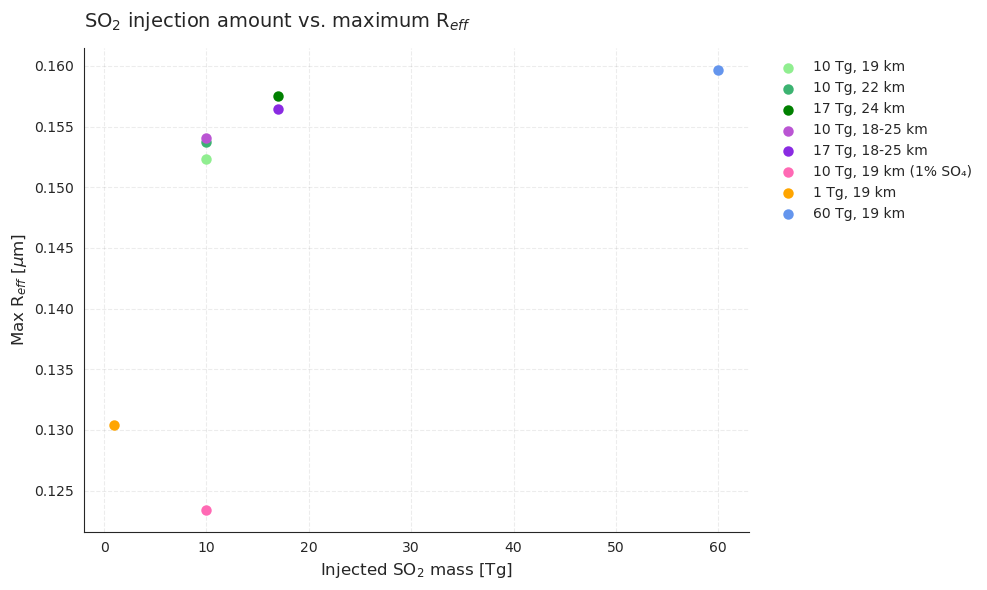

In [34]:
cm_to_mym = 10000

sns.set_style("white")
fig, ax = plt.subplots(figsize=(10, 6))
ax.grid(color="gray", alpha=0.15, linestyle="--", zorder=0)
ax.scatter(10, reff_max_values[0], color="lightgreen", lw=1.5,label="10 Tg, 19 km")
ax.scatter(10, reff_max_values[2],color="mediumseagreen", lw=1.5,label="10 Tg, 22 km")
ax.scatter(17, reff_max_values[3],color="green", lw=1.5,label="17 Tg, 24 km")
ax.scatter(10, reff_max_values[4],color="mediumorchid", lw=1.5,label="10 Tg, 18-25 km")
ax.scatter(17, reff_max_values[5],color="blueviolet", lw=1.5,label="17 Tg, 18-25 km")
ax.scatter(10, reff_max_values[7],color="hotpink", lw=1.5,label="10 Tg, 19 km (1% SO₄)")
ax.scatter(1, reff_max_values[6], color="orange", lw=1.5, label="1 Tg, 19 km")
ax.scatter(60, reff_max_values[1],color="cornflowerblue", lw=1.5,label="60 Tg, 19 km ")

ax.set_xlabel("Injected SO$_2$ mass [Tg]", fontsize=12)
ax.set_ylabel("Max R$_{eff}$ [$\mu$m]", fontsize=12)
ax.set_title("SO$_2$ injection amount vs. maximum R$_{eff}$ ", loc="left", fontsize=14, pad=15)

ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

sns.despine()
plt.tight_layout()
plt.show()

<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_3128147/1610896650.py:14: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel("Max R$_{eff}$ [$\mu$m]", fontsize=12)


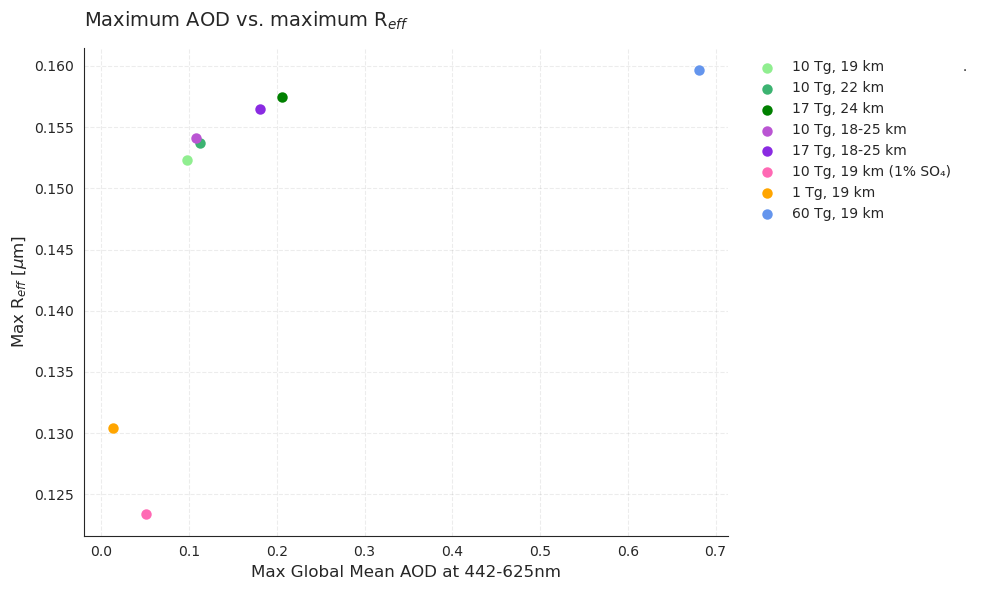

In [35]:
sns.set_style("white")
fig, ax = plt.subplots(figsize=(10, 6))
ax.grid(color="gray", alpha=0.15, linestyle="--", zorder=0)
plt.scatter(aod_19_c_max, reff_max_values[0], color="lightgreen", lw=1.5,label="10 Tg, 19 km                  . ")
plt.scatter(aod_22_max, reff_max_values[2],color="mediumseagreen", lw=1.5,label="10 Tg, 22 km")
plt.scatter(aod_24_max, reff_max_values[3],color="green", lw=1.5,label="17 Tg, 24 km")
plt.scatter(aod_1825_max, reff_max_values[4],color="mediumorchid", lw=1.5,label="10 Tg, 18-25 km")
plt.scatter(aod_1825_17tg_max, reff_max_values[5],color="blueviolet", lw=1.5,label="17 Tg, 18-25 km")
plt.scatter(aod_1pr_max, reff_max_values[7],color="hotpink", lw=1.5,label="10 Tg, 19 km (1% SO₄)")
plt.scatter(aod_1tg_max, reff_max_values[6], color="orange", lw=1.5, label="1 Tg, 19 km")
plt.scatter(aod_60tg_max, reff_max_values[1],color="cornflowerblue", lw=1.5,label="60 Tg, 19 km ")

ax.set_xlabel("Max Global Mean AOD at 442-625nm", fontsize=12)
ax.set_ylabel("Max R$_{eff}$ [$\mu$m]", fontsize=12)
ax.set_title("Maximum AOD vs. maximum R$_{eff}$ ", loc="left", fontsize=14, pad=15)

ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

sns.despine()
plt.tight_layout()
plt.show()

<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_3128147/651964837.py:13: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel("Max R$_{eff}$ [$\mu$m]", fontsize=12)


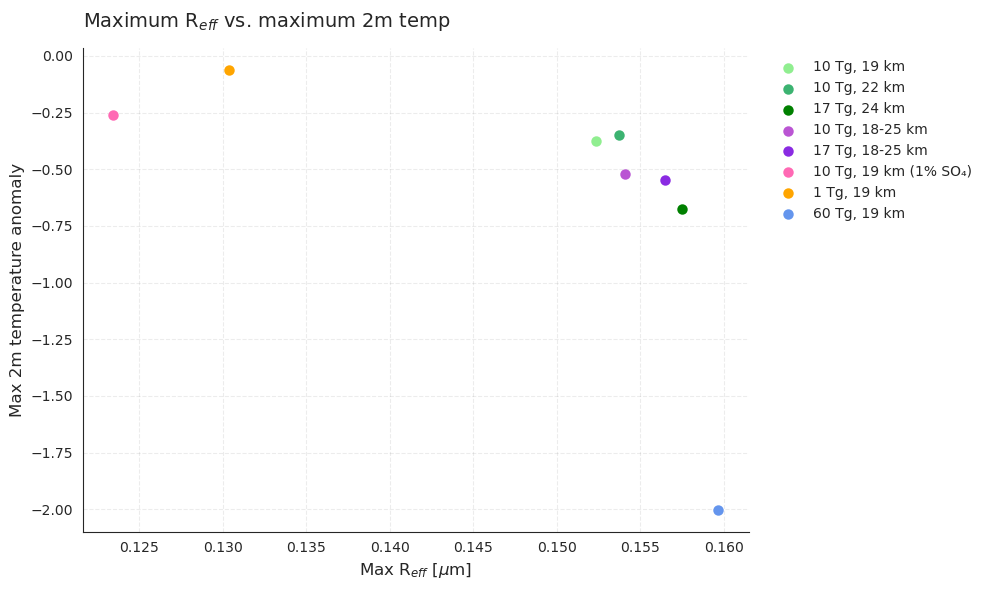

In [36]:
sns.set_style("white")
fig, ax = plt.subplots(figsize=(10, 6))
ax.grid(color="gray", alpha=0.15, linestyle="--", zorder=0)
plt.scatter(reff_max_values[0], t_anom_19_c_max, color="lightgreen", lw=1.5,label="10 Tg, 19 km")
plt.scatter(reff_max_values[2], t_anom_22max, color="mediumseagreen", lw=1.5,label="10 Tg, 22 km")
plt.scatter(reff_max_values[3], t_anom_24_max, color="green", lw=1.5,label="17 Tg, 24 km")
plt.scatter(reff_max_values[4], t_anom_1825_max, color="mediumorchid", lw=1.5,label="10 Tg, 18-25 km")
plt.scatter(reff_max_values[5], t_anom_1825_17tg_max, color="blueviolet", lw=1.5,label="17 Tg, 18-25 km")
plt.scatter(reff_max_values[7], t_anom_1pr_max, color="hotpink", lw=1.5,label="10 Tg, 19 km (1% SO₄)")
plt.scatter(reff_max_values[6], t_anom_1tg_max, color="orange", lw=1.5, label="1 Tg, 19 km")
plt.scatter(reff_max_values[1], t_anom_60tg_max, color="cornflowerblue", lw=1.5,label="60 Tg, 19 km ")

ax.set_xlabel("Max R$_{eff}$ [$\mu$m]", fontsize=12)
ax.set_ylabel("Max 2m temperature anomaly", fontsize=12)
ax.set_title("Maximum R$_{eff}$ vs. maximum 2m temp", loc="left", fontsize=14, pad=15)

ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

sns.despine()
plt.tight_layout()
plt.show()

In [37]:
cb_O3_19 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/cb_O3_h0_1975-2014.nc")
shifted_time_19 = np.array([shift_one_month_back(t) for t in cb_O3_19['time'].values])
cb_O3_19 = cb_O3_19.assign_coords(time=shifted_time_19)
cb_O3_19_c = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg19/NHIST_tropstratchem_f09_tn14_20260116_Pinatubo10Tg19_02/cb_O3_h0_1991-1995.nc")
shifted_time_19_c = np.array([shift_one_month_back(t) for t in cb_O3_19_c['time'].values])
cb_O3_19_c = cb_O3_19_c.assign_coords(time=shifted_time_19_c)
cb_O3_22 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10Tg22/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01/cb_O3_h0_1991-1995.nc")
shifted_time_22 = np.array([shift_one_month_back(t) for t in cb_O3_22['time'].values])
cb_O3_22 = cb_O3_22.assign_coords(time=shifted_time_22)
cb_O3_24 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg24/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01/cb_O3_h0_1991-1995.nc")
shifted_time_24 = np.array([shift_one_month_back(t) for t in cb_O3_24['time'].values])
cb_O3_24 = cb_O3_24.assign_coords(time=shifted_time_24)
cb_O3_1825_17tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg1825/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01/cb_O3_h0_1991-1995.nc")
shifted_time_1825_17tg = np.array([shift_one_month_back(t) for t in cb_O3_1825_17tg['time'].values])
cb_O3_1825_17tg = cb_O3_1825_17tg.assign_coords(time=shifted_time_1825_17tg)
cb_O3_1825 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg1825/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01/cb_O3_h0_1991-1995.nc")
shifted_time_1825 = np.array([shift_one_month_back(t) for t in cb_O3_1825['time'].values])
cb_O3_1825 = cb_O3_1825.assign_coords(time=shifted_time_1825)
cb_O3_1tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_1tg19/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01/cb_O3_h0_1991-1995.nc")
shifted_time_1tg = np.array([shift_one_month_back(t) for t in cb_O3_1tg['time'].values])
cb_O3_1tg = cb_O3_1tg.assign_coords(time=shifted_time_1tg)
cb_O3_1pr = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg_1pr/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr/cb_O3_h0_1991-1995.nc")
shifted_time_1pr = np.array([shift_one_month_back(t) for t in cb_O3_1pr['time'].values])
cb_O3_1pr = cb_O3_1pr.assign_coords(time=shifted_time_1pr)
cb_O3_60tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_60tg19/NHIST_tropstratchem_f09_tn14_20260107_Pinatubo60Tg19/cb_O3_h0_1991-1995.nc")
shifted_time_60tg = np.array([shift_one_month_back(t) for t in cb_O3_60tg['time'].values])
cb_O3_60tg = cb_O3_60tg.assign_coords(time=shifted_time_60tg)

In [38]:
DU = 1.0 / 2.1415e-05
cb_o3 = "cb_O3"

In [39]:
def calc_anomaly(ds, weights, baseline_obj, lat_range=None):
    var = "cb_O3" 
    
    if lat_range:
        data = ds[var].sel(lat=slice(*lat_range))
        w = weights.sel(lat=slice(*lat_range))
    else:
        data = ds[var]
        w = weights
        
    mean_ts = data.weighted(w).mean(dim=["lat", "lon"]) * DU
    anom = mean_ts.groupby("time.month") - baseline_obj
    return anom.sel(time=slice('1991-01-01', '1996-01-01'))

In [40]:
o3_glob = cb_O3_19["cb_O3"].weighted(weighted_lat_19).mean(dim=["lat", "lon"]) * DU
base_global = o3_glob.sel(time=slice("1986", "1990")).groupby("time.month").mean()

In [41]:
o3_anom = calc_anomaly(cb_O3_19, weighted_lat_19, base_global)
o3_19_c_anom = calc_anomaly(cb_O3_19_c, weighted_lat_19_c, base_global)
o3_22_anom = calc_anomaly(cb_O3_22, weighted_lat_22, base_global)
o3_24_anom = calc_anomaly(cb_O3_24, weighted_lat_24, base_global)
o3_1825_anom = calc_anomaly(cb_O3_1825, weighted_lat_1825, base_global)
o3_1825_17tg_anom = calc_anomaly(cb_O3_1825_17tg, weighted_lat_1825_17tg, base_global)
o3_1pr_anom = calc_anomaly(cb_O3_1pr, weighted_lat_1pr, base_global)
o3_1tg_anom = calc_anomaly(cb_O3_1tg, weighted_lat_1tg, base_global)
o3_60tg_anom = calc_anomaly(cb_O3_60tg, weighted_lat_60tg, base_global)

In [42]:
max_ozone_19 = min(o3_anom)
max_ozone_19_c = min(o3_19_c_anom)
max_ozone_22 = min(o3_22_anom)
max_ozone_24 = min(o3_24_anom)
max_ozone_1825 = min(o3_1825_anom)
max_ozone_1825_17tg = min(o3_1825_17tg_anom)
max_ozone_1pr = min(o3_1pr_anom)
max_ozone_1tg = min(o3_1tg_anom)
max_ozone_60tg = min(o3_60tg_anom)

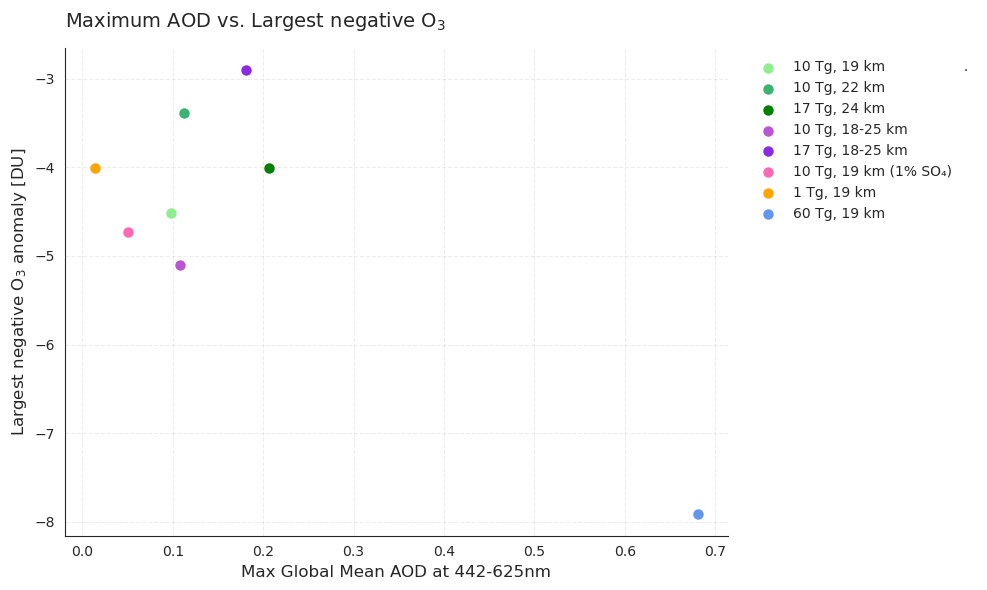

In [43]:
sns.set_style("white")
fig, ax = plt.subplots(figsize=(10, 6))
ax.grid(color="gray", alpha=0.15, linestyle="--", zorder=0)
plt.scatter(aod_19_c_max, max_ozone_19_c, color="lightgreen", lw=1.5,label="10 Tg, 19 km                  . ")
plt.scatter(aod_22_max, max_ozone_22,color="mediumseagreen", lw=1.5,label="10 Tg, 22 km")
plt.scatter(aod_24_max, max_ozone_24,color="green", lw=1.5,label="17 Tg, 24 km")
plt.scatter(aod_1825_max, max_ozone_1825,color="mediumorchid", lw=1.5,label="10 Tg, 18-25 km")
plt.scatter(aod_1825_17tg_max, max_ozone_1825_17tg,color="blueviolet", lw=1.5,label="17 Tg, 18-25 km")
plt.scatter(aod_1pr_max, max_ozone_1pr,color="hotpink", lw=1.5,label="10 Tg, 19 km (1% SO₄)")
plt.scatter(aod_1tg_max, max_ozone_1tg, color="orange", lw=1.5, label="1 Tg, 19 km")
plt.scatter(aod_60tg_max, max_ozone_60tg,color="cornflowerblue", lw=1.5,label="60 Tg, 19 km ")

ax.set_xlabel("Max Global Mean AOD at 442-625nm", fontsize=12)
ax.set_ylabel("Largest negative O$_3$ anomaly [DU]", fontsize=12)
ax.set_title("Maximum AOD vs. Largest negative O$_3$ ", loc="left", fontsize=14, pad=15)

ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

sns.despine()
plt.tight_layout()
plt.show()

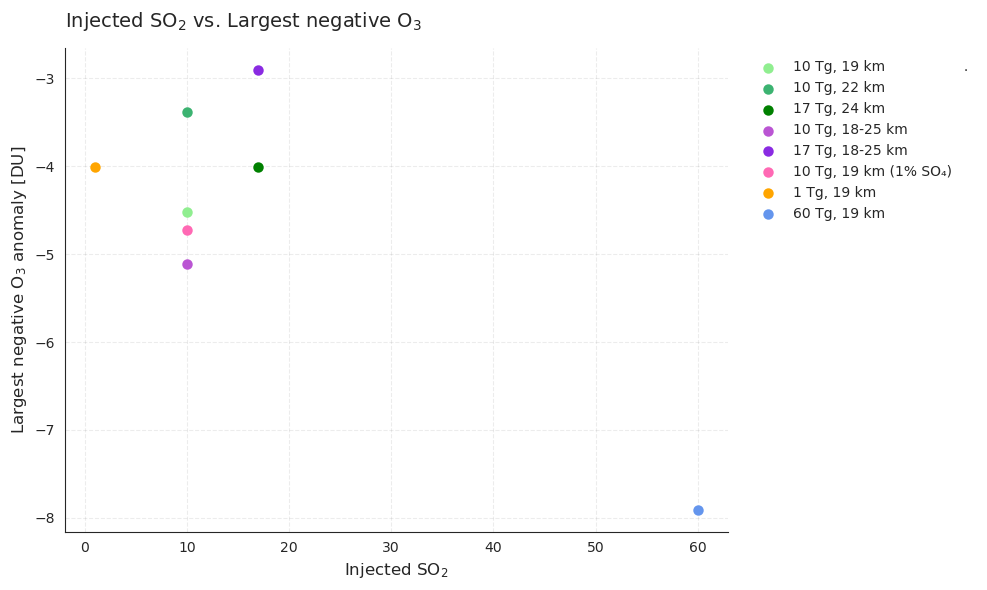

In [44]:
sns.set_style("white")
fig, ax = plt.subplots(figsize=(10, 6))
ax.grid(color="gray", alpha=0.15, linestyle="--", zorder=0)
plt.scatter(10, max_ozone_19_c, color="lightgreen", lw=1.5,label="10 Tg, 19 km                  . ")
plt.scatter(10, max_ozone_22,color="mediumseagreen", lw=1.5,label="10 Tg, 22 km")
plt.scatter(17, max_ozone_24,color="green", lw=1.5,label="17 Tg, 24 km")
plt.scatter(10, max_ozone_1825,color="mediumorchid", lw=1.5,label="10 Tg, 18-25 km")
plt.scatter(17, max_ozone_1825_17tg,color="blueviolet", lw=1.5,label="17 Tg, 18-25 km")
plt.scatter(10, max_ozone_1pr,color="hotpink", lw=1.5,label="10 Tg, 19 km (1% SO₄)")
plt.scatter(1, max_ozone_1tg, color="orange", lw=1.5, label="1 Tg, 19 km")
plt.scatter(60, max_ozone_60tg,color="cornflowerblue", lw=1.5,label="60 Tg, 19 km ")

ax.set_xlabel("Injected SO$_2$", fontsize=12)
ax.set_ylabel("Largest negative O$_3$ anomaly [DU]", fontsize=12)
ax.set_title("Injected SO$_2$ vs. Largest negative O$_3$ ", loc="left", fontsize=14, pad=15)

ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

sns.despine()
plt.tight_layout()
plt.show()

In [45]:
EC550SO4_19_c = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg19/NHIST_tropstratchem_f09_tn14_20260116_Pinatubo10Tg19_02/EC550SO4_h0_1991-1995.nc")
shifted_time_19_c = np.array([shift_one_month_back(t) for t in EC550SO4_19_c['time'].values])
EC550SO4_19_c = EC550SO4_19_c.assign_coords(time=shifted_time_19_c)
EC550SO4_22 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10Tg22/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01/EC550SO4_h0_1991-1995.nc")
shifted_time_22 = np.array([shift_one_month_back(t) for t in EC550SO4_22['time'].values])
EC550SO4_22 = EC550SO4_22.assign_coords(time=shifted_time_22)
EC550SO4_24 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg24/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01/EC550SO4_h0_1991-1995.nc")
shifted_time_24 = np.array([shift_one_month_back(t) for t in EC550SO4_24['time'].values])
EC550SO4_24 = EC550SO4_24.assign_coords(time=shifted_time_24)
EC550SO4_1825_17tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg1825/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01/EC550SO4_h0_1991-1995.nc")
shifted_time_1825_17tg = np.array([shift_one_month_back(t) for t in EC550SO4_1825_17tg['time'].values])
EC550SO4_1825_17tg = EC550SO4_1825_17tg.assign_coords(time=shifted_time_1825_17tg)
EC550SO4_1825 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg1825/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01/EC550SO4_h0_1991-1995.nc")
shifted_time_1825 = np.array([shift_one_month_back(t) for t in EC550SO4_1825['time'].values])
EC550SO4_1825 = EC550SO4_1825.assign_coords(time=shifted_time_1825)
EC550SO4_1tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_1tg19/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01/EC550SO4_h0_1991-1995.nc")
shifted_time_1tg = np.array([shift_one_month_back(t) for t in EC550SO4_1tg['time'].values])
EC550SO4_1tg = EC550SO4_1tg.assign_coords(time=shifted_time_1tg)
EC550SO4_1pr = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg_1pr/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr/EC550SO4_h0_1991-1995.nc")
shifted_time_1pr = np.array([shift_one_month_back(t) for t in EC550SO4_1pr['time'].values])
EC550SO4_1pr = EC550SO4_1pr.assign_coords(time=shifted_time_1pr)
EC550SO4_60tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_60tg19/NHIST_tropstratchem_f09_tn14_20260107_Pinatubo60Tg19/EC550SO4_h0_1991-1995.nc")
shifted_time_60tg = np.array([shift_one_month_back(t) for t in EC550SO4_60tg['time'].values])
EC550SO4_60tg = EC550SO4_60tg.assign_coords(time=shifted_time_60tg)

In [46]:
def get_weighted_extinction(ds, p_lev, lat_min=-90, lat_max=90):
    ds_area = ds.sel(lat=slice(lat_min, lat_max))
    
    weights_lat = np.cos(np.deg2rad(ds_area.lat))
    weights_lat.name = "weights"
    
    lev_vals = ds_area.lev.values
    lev_diff = np.abs(np.gradient(lev_vals))
    wl = xr.DataArray(lev_diff, coords={'lev': ds_area.lev}, dims=['lev'])
    
    ec = ds_area["EC550SO4"].where(ds_area["lev"] <= p_lev)
    ec_h = ec.weighted(weights_lat).mean(dim=["lat", "lon"])
    ec_final = ec_h.weighted(wl).mean(dim="lev")
    
    return ec_final

In [47]:
ec_19_c = get_weighted_extinction(EC550SO4_19_c, p_lev_19_c)
ec_22 = get_weighted_extinction(EC550SO4_22, p_lev_22)
ec_24 = get_weighted_extinction(EC550SO4_24, p_lev_24)
ec_1825= get_weighted_extinction(EC550SO4_1825, p_lev_1825)
ec_1825_17tg = get_weighted_extinction(EC550SO4_1825_17tg, p_lev_1825_17tg)
ec_1tg = get_weighted_extinction(EC550SO4_1tg, p_lev_1tg)
ec_1pr = get_weighted_extinction(EC550SO4_1pr, p_lev_1pr)
ec_60tg= get_weighted_extinction(EC550SO4_60tg, p_lev_60tg)

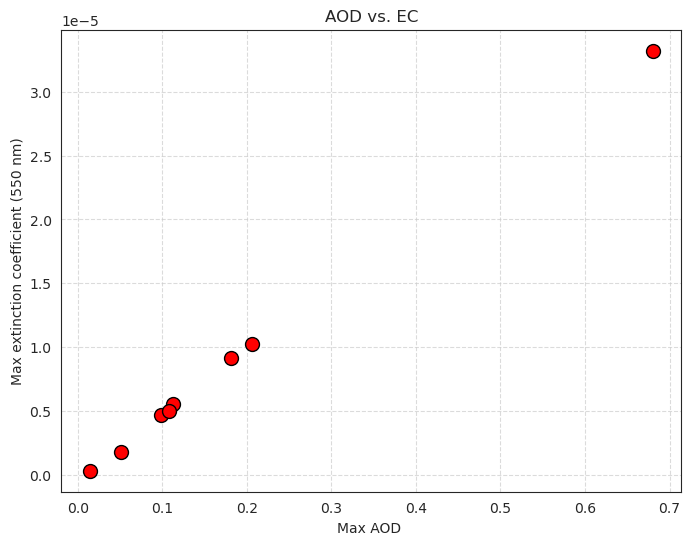

In [48]:
all_max_ext = []

datasets = [ec_19_c, ec_22, ec_24, ec_1825, ec_1825_17tg, ec_1tg, ec_1pr, ec_60tg] 

for ds in datasets:
    all_max_ext.append(ds.max().values)

all_max_aod = [aod_19_c_max, aod_22_max, aod_24_max, aod_1825_max, aod_1825_17tg_max, aod_1tg_max, aod_1pr_max, aod_60tg_max]

plt.figure(figsize=(8, 6))
plt.scatter(all_max_aod, all_max_ext, color='red', s=100, edgecolors='black')

plt.xlabel('Max AOD ')
plt.ylabel('Max extinction coefficient (550 nm)')
plt.title('AOD vs. EC')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:52: SyntaxWarning: invalid escape sequence '\c'
<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:52: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_3128147/3066121378.py:14: SyntaxWarning: invalid escape sequence '\m'
  ax[0,0].set_ylabel("Maximum R$_{eff}$ [$\mu m$]", fontsize=12)
/tmp/ipykernel_3128147/3066121378.py:52: SyntaxWarning: invalid escape sequence '\c'
  ax[1,1].set_ylabel("Minumum temperature [$^\circ$C]", fontsize=12)


Text(0.5, 0.98, 'Scatterplots for comparing AOD with R$_{eff}$, EC, O$_3$, T$_{2m}$')

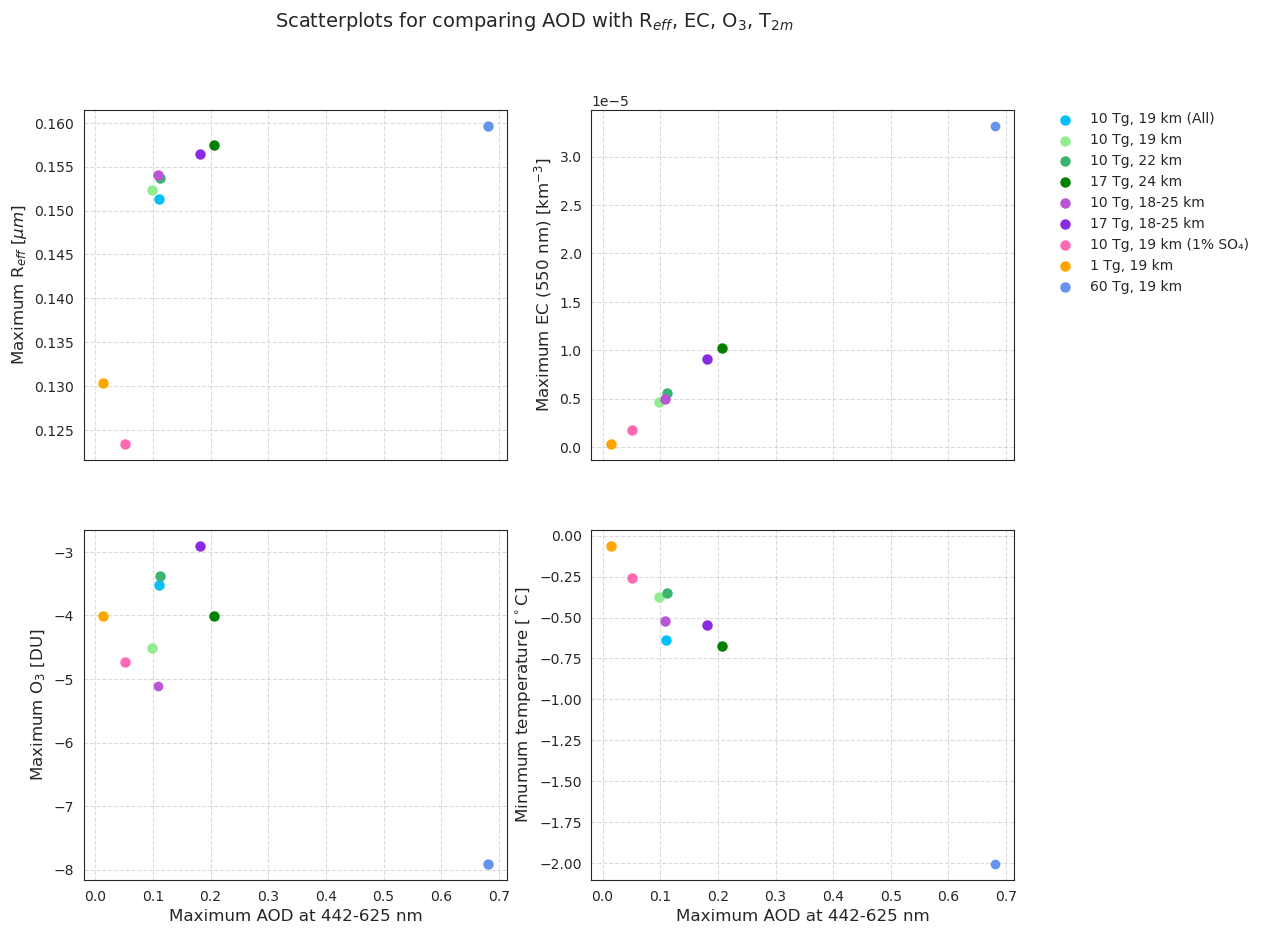

In [49]:
fig, ax = plt.subplots(2,2, figsize=(12, 10), sharex=True)

ax[0,0].scatter(aod_19_max, reffaero_19_max, color = "deepskyblue", lw=1.5, label="10 Tg, 19 km (All)")
ax[0,0].scatter(aod_19_c_max, reff_max_values[0], color="lightgreen", lw=1.5,label="10 Tg, 19 km")
ax[0,0].scatter(aod_22_max, reff_max_values[2],color="mediumseagreen", lw=1.5,label="10 Tg, 22 km")
ax[0,0].scatter(aod_24_max, reff_max_values[3], color="green", lw=1.5,label="17 Tg, 24 km")
ax[0,0].scatter(aod_1825_max, reff_max_values[4],color="mediumorchid", lw=1.5,label="10 Tg, 18-25 km")
ax[0,0].scatter(aod_1825_17tg_max, reff_max_values[5],color="blueviolet", lw=1.5,label="17 Tg, 18-25 km")
ax[0,0].scatter(aod_1pr_max, reff_max_values[7], color="hotpink", lw=1.5,label="10 Tg, 19 km (1% SO₄)")
ax[0,0].scatter(aod_1tg_max, reff_max_values[6], color="orange", lw=1.5, label="1 Tg, 19 km")
ax[0,0].scatter(aod_60tg_max, reff_max_values[1],color="cornflowerblue", lw=1.5,label="60 Tg, 19 km ")
ax[0,0].grid(True, alpha=0.7, ls="--")
ax[0,0].set_xlabel(" ")
ax[0,0].set_ylabel("Maximum R$_{eff}$ [$\mu m$]", fontsize=12)

ax[0,1].scatter(aod_19_c_max, all_max_ext[0], color="lightgreen", lw=1.5) #,label="10 Tg, 19 km")
ax[0,1].scatter(aod_22_max, all_max_ext[1],color="mediumseagreen", lw=1.5) #,label="10 Tg, 22 km")
ax[0,1].scatter(aod_24_max, all_max_ext[2],color="green", lw=1.5) #,label="17 Tg, 24 km")
ax[0,1].scatter(aod_1825_max, all_max_ext[3],color="mediumorchid", lw=1.5) #,label="10 Tg, 18-25 km")
ax[0,1].scatter(aod_1825_17tg_max, all_max_ext[4],color="blueviolet", lw=1.5) #,label="17 Tg, 18-25 km")
ax[0,1].scatter(aod_1pr_max, all_max_ext[6],color="hotpink", lw=1.5) #, label="10 Tg, 19 km (1% SO₄)")
ax[0,1].scatter(aod_1tg_max, all_max_ext[5], color="orange", lw=1.5) #, label="1 Tg, 19 km")
ax[0,1].scatter(aod_60tg_max, all_max_ext[7],color="cornflowerblue") #, lw=1.5,label="60 Tg, 19 km ")
ax[0,1].grid(True, alpha=0.7, ls="--")
ax[0,1].set_xlabel(" ")
ax[0,1].set_ylabel("Maximum EC (550 nm) [km$^{-3}$]", fontsize=12)

ax[1,0].scatter(aod_19_max, max_ozone_19, color="deepskyblue", lw=1.5)
ax[1,0].scatter(aod_19_c_max, max_ozone_19_c, color="lightgreen", lw=1.5) #,label="10 Tg, 19 km"
ax[1,0].scatter(aod_22_max, max_ozone_22,color="mediumseagreen", lw=1.5) #,label="10 Tg, 22 km")
ax[1,0].scatter(aod_24_max, max_ozone_24, color="green", lw=1.5) #,label="17 Tg, 24 km")
ax[1,0].scatter(aod_1825_max, max_ozone_1825,color="mediumorchid") #, lw=1.5,label="10 Tg, 18-25 km")
ax[1,0].scatter(aod_1825_17tg_max, max_ozone_1825_17tg, color="blueviolet", lw=1.5) #,label="17 Tg, 18-25 km")
ax[1,0].scatter(aod_1pr_max, max_ozone_1pr, color="hotpink", lw=1.5) #,label="10 Tg, 19 km (1% SO₄)")
ax[1,0].scatter(aod_1tg_max, max_ozone_1tg, color="orange", lw=1.5) #, label="1 Tg, 19 km")
ax[1,0].scatter(aod_60tg_max, max_ozone_60tg, color="cornflowerblue", lw=1.5) #,label="60 Tg, 19 km ")
ax[1,0].grid(True, alpha=0.7, ls="--")
ax[1,0].set_xlabel("Maximum AOD at 442-625 nm", fontsize=12)
ax[1,0].set_ylabel("Maximum O$_3$ [DU]", fontsize=12)

ax[1,1].scatter(aod_19_max, t_anom_19_max, color = "deepskyblue", lw = 1.5)
ax[1,1].scatter(aod_19_c_max, t_anom_19_c_max, color="lightgreen", lw=1.5) #,label="10 Tg, 19 km")
ax[1,1].scatter(aod_22_max, t_anom_22max,color="mediumseagreen", lw=1.5) #,label="10 Tg, 22 km")
ax[1,1].scatter(aod_24_max, t_anom_24_max,color="green", lw=1.5) #,label="17 Tg, 24 km")
ax[1,1].scatter(aod_1825_max, t_anom_1825_max,color="mediumorchid", lw=1.5) #,label="10 Tg, 18-25 km")
ax[1,1].scatter(aod_1825_17tg_max, t_anom_1825_17tg_max,color="blueviolet", lw=1.5) #,label="17 Tg, 18-25 km")
ax[1,1].scatter(aod_1pr_max, t_anom_1pr_max,color="hotpink", lw=1.5) #, label="10 Tg, 19 km (1% SO₄)")
ax[1,1].scatter(aod_1tg_max, t_anom_1tg_max, color="orange", lw=1.5) #, label="1 Tg, 19 km")
ax[1,1].scatter(aod_60tg_max, t_anom_60tg_max,color="cornflowerblue") #, lw=1.5,label="60 Tg, 19 km ")
ax[1,1].grid(True, alpha=0.7, ls="--")
ax[1,1].set_xlabel("Maximum AOD at 442-625 nm", fontsize=12)
ax[1,1].set_ylabel("Minumum temperature [$^\circ$C]", fontsize=12)

fig.legend(bbox_to_anchor=(0.92, 0.89), loc='upper left', frameon=False)

#plt.tight_layout
plt.suptitle("Scatterplots for comparing AOD with R$_{eff}$, EC, O$_3$, T$_{2m}$", fontsize=14)